## Version Test

In [37]:
import sys
assert sys.version_info >= (3, 7)
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

## 1 Dataset & Problem Definition
### 1.1 Dataset Description:
This dataset consists of sales transaction records from multiple pharmacies, with 62,139 rows in total. The original data is stored in a star schema, comprising one sales fact table (FactSales) and three dimension tables (DimDate for dates, DimPharmacy for pharmacy information, and DimProduct for product information). Before modeling, we left-join the four tables using their corresponding keys to create a consolidated analysis table with 34 columns.

### 1.2 Problem Definition (Regression Use Case):
####  1.2.1 Continuous Target: 
RevenueEUR: the revenue generated by each transaction, represented by each sales record.
####  1.2.2 Goal: 
Assuming that units sold are known at prediction time, the model uses store size, pharmacy type, product standard cost, list price, and units sold to predict the revenue of each sales record. The predictions can support revenue estimation and help identify records with large differences between predicted and actual revenue.

## 2 Exploratory Data Analysis

### Data Import and Table Merging

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load and merge the Star Schema into a single master dataframe
xls = pd.ExcelFile("Pharmacy_data.xlsx")
df_sales = pd.read_excel(xls, sheet_name='FactSales')
df_date = pd.read_excel(xls, sheet_name='DimDate')
df_pharmacy = pd.read_excel(xls, sheet_name='DimPharmacy')
df_product = pd.read_excel(xls, sheet_name='DimProduct')

# Left join dimensions to the fact table
df = df_sales.merge(df_date, on='DateKey', how='left')\
             .merge(df_pharmacy, on='PharmacyID', how='left')\
             .merge(df_product, on='ProductID', how='left')

## 2.1 Target Variable Distribution

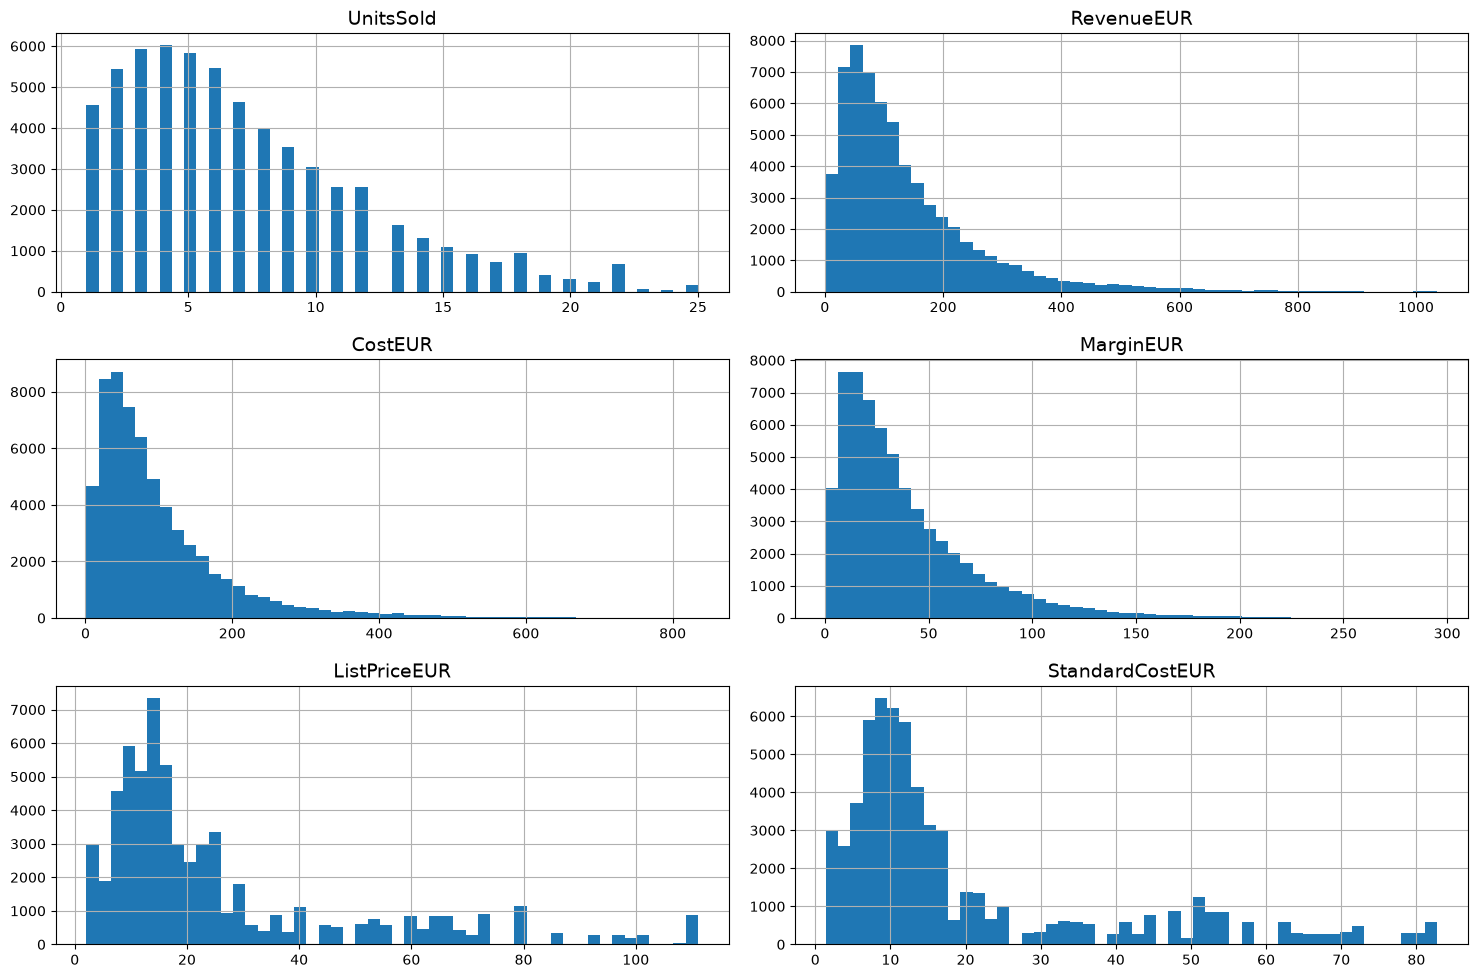

In [39]:
from pathlib import Path

# 1. Set up high-resolution figure saving and formatting
IMAGES_PATH = Path() / "images" / "pharmacy_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Set the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# 2. Plot histograms of selected numerical columns
numeric_cols = ['UnitsSold', 'RevenueEUR', 'CostEUR', 'MarginEUR', 'ListPriceEUR', 'StandardCostEUR']

# Use the merged dataframe for plotting
df[numeric_cols].hist(bins=50, figsize=(15, 10))
save_fig("pharmacy_attribute_histogram_plots")
plt.show()

The target variable shows a strongly right-skewed distribution: most sales records have relatively low revenue. This pattern is plausible in retail, where routine medication purchases are often small, while large one-time purchases or frequent bulk purchases are less common. Therefore, a log transformation may be useful during feature engineering to reduce the influence of high-value records on model training.

### 2.2 Correlation Matrix

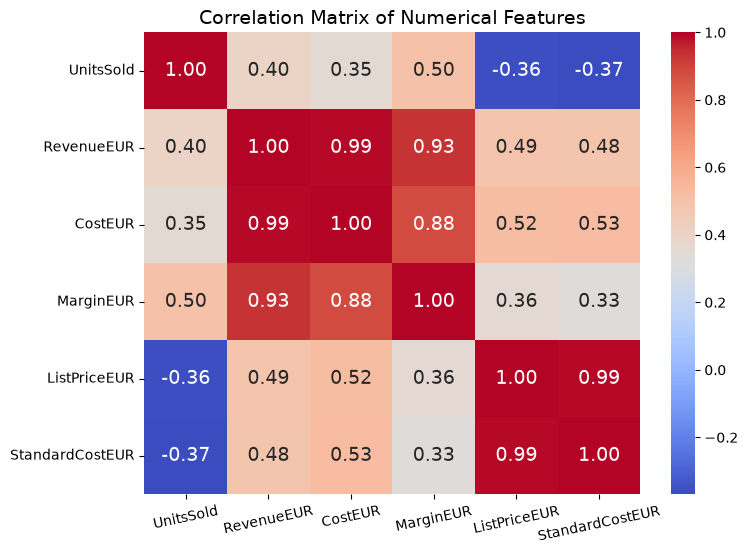

In [40]:
numeric_cols = ['UnitsSold', 'RevenueEUR', 'CostEUR', 'MarginEUR', 'ListPriceEUR', 'StandardCostEUR']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=12)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix shows that RevenueEUR is strongly positively correlated with CostEUR and MarginEUR, with correlation coefficients of approximately 0.99 and 0.93, respectively. MarginEUR is calculated as RevenueEUR minus CostEUR, so using it as a feature would leak information about the target. CostEUR is the actual transaction cost, which is not assumed to be known at prediction time in this use case. The model therefore excludes both variables.

Assuming UnitsSold is known at prediction time, the model uses store size, pharmacy type, standard cost, list price, and units sold to predict revenue. Standard cost and list price are also strongly correlated in this dataset, possibly because products with higher costs tend to have higher list prices. This makes their individual linear regression coefficients harder to interpret. Since the analysis focuses on prediction, both features are retained, and model performance is evaluated using training and test errors.

### 2.3 Boxplot of Revenue by Categorical Feature

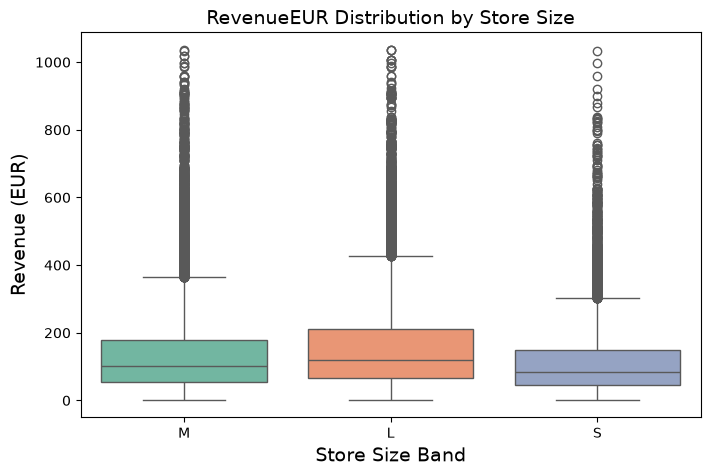

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='StoreSizeBand', y='RevenueEUR', data=df, hue='StoreSizeBand', palette='Set2', legend=False)
plt.title('RevenueEUR Distribution by Store Size')
plt.xlabel('Store Size Band')
plt.ylabel('Revenue (EUR)')
plt.show()

Sales records from large pharmacies (L) have a higher median revenue and a higher upper whisker than those from medium (M) and small (S) pharmacies. This suggests that store size may be associated with revenue, so `StoreSizeBand` is included as a categorical feature. Its usefulness for prediction will be assessed through the model results.

## 3 Feature Engineering & Preprocessing

### 3.1 Clean the Data 
'DiscontinuedDate' has 57,094 missing values (over 90% missing rate), all associated with products marked `IsDiscontinued = "No"`. These products have no discontinuation date, so filling the missing values with a date would be misleading. We exclude this column because it is not used in the model. The selected predictors and `RevenueEUR` have no missing values.

In [42]:
df_clean = df.drop(columns=['DiscontinuedDate'])

### 3.2 Define our features and target

In [43]:
features = ['StoreSizeBand', 'PharmacyType', 'StandardCostEUR', 'ListPriceEUR', 'UnitsSold']
X = df_clean[features]
y = df_clean['RevenueEUR']

### 3.3 Create a Train Set and Test Set

In [44]:
from sklearn.model_selection import train_test_split
# Split data FIRST to prevent data leakage during scaling/encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)

In [45]:
# Check for missing values in the selected training features
print(X_train.isnull().sum())

StoreSizeBand      0
PharmacyType       0
StandardCostEUR    0
ListPriceEUR       0
UnitsSold          0
dtype: int64


### 3.4 Main Preprocessing Pipeline

#### 3.4.1 Feature Classification

In [46]:
num_features = ['StandardCostEUR', 'ListPriceEUR', 'UnitsSold']
cat_features = ['StoreSizeBand', 'PharmacyType']

#### 3.4.2 Standardization - StandardScaler, One-Hot Encoding

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# We use ColumnTransformer to apply different transformations to specific columns
preprocessor = ColumnTransformer(
    transformers=[
        # Method 1: Scaling. Standardize numerical features to have mean=0 and variance=1.
        ('num', StandardScaler(), num_features),
        # Method 2: One-Hot Encoding. Convert unordered categorical text into dummy binary columns.
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Apply transformations to training data
X_train_processed = preprocessor.fit_transform(X_train)
# Apply the FITTED transformations to test data
X_test_processed = preprocessor.transform(X_test)

ColumnTransformer is a Scikit-Learn estimator that allows heterogeneous data arrays to be transformed by applying specific transformer objects to distinct subsets of columns, seamlessly combining the processed outputs into a single unified feature matrix.

fit_transform learns the scaling parameters or category mappings from the training data and applies the transformation in one step. transform strictly applies the previously learned parameters to new data (like the test set) without re-calculating any new parameters.

One-Hot Encoding is perfect for 'StoreSizeBand' because it is a low-cardinality feature that only includes three categories: Large, Medium, and Small.

#### 3.4.3 Log Transformation (Handling Outliers/Skewness)

In [48]:
# As seen in EDA Plot 1, the target is highly right-skewed. We apply log1p.
# Identify high-revenue records using the training set only
q1, q3 = y_train.quantile([0.25, 0.75])
upper_bound = q3 + 1.5 * (q3 - q1)
high_value_count = (y_train > upper_bound).sum()

print(f"IQR upper bound: €{upper_bound:.2f}")
print(f"Records above the bound: {high_value_count:,} ({high_value_count / len(y_train):.2%})")

# Keep these records and reduce their influence during training
y_train_log = np.log1p(y_train)

IQR upper bound: €371.30
Records above the bound: 2,725 (5.48%)


The IQR upper bound for training-set revenue is €371.30, and 2,725 records (5.48%) exceed it. <br>
These high values are retained because exceeding the IQR bound does not necessarily mean a sale is erroneous. Applying "log1p" to the training target reduces their influence during model fitting; predictions are converted back to euros for evaluation.

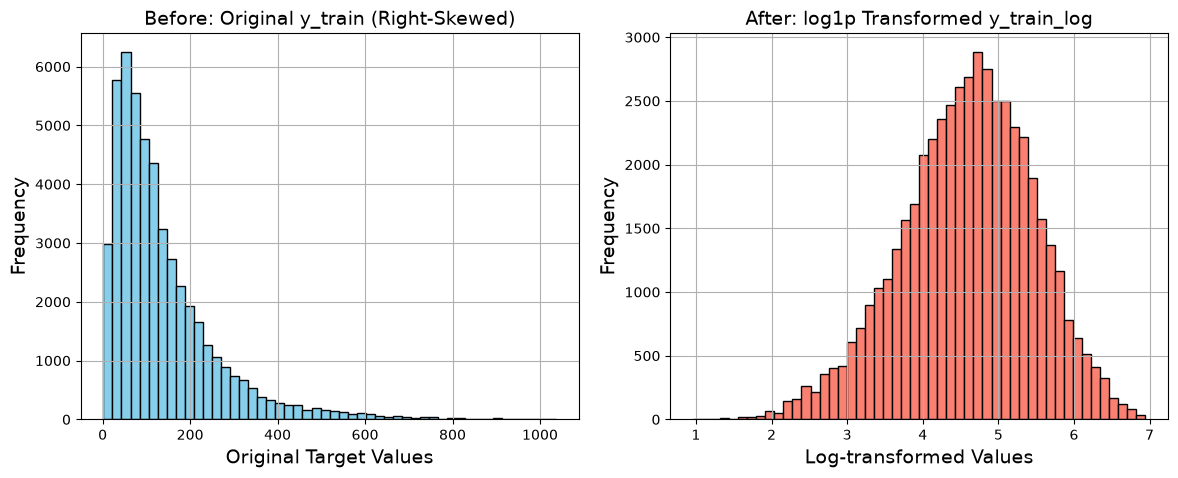

In [49]:
import matplotlib.pyplot as plt

# Create a wide figure to compare the distributions before and after transformation
plt.figure(figsize=(12, 5))

# Left: original target values
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, color='skyblue', edgecolor='black')
plt.title('Before: Original y_train (Right-Skewed)')
plt.xlabel('Original Target Values')
plt.ylabel('Frequency')
plt.grid(True)

# Right: target values after log1p transformation
plt.subplot(1, 2, 2)
plt.hist(y_train_log, bins=50, color='salmon', edgecolor='black')
plt.title('After: log1p Transformed y_train_log')
plt.xlabel('Log-transformed Values')
plt.ylabel('Frequency')
plt.grid(True)

# Save the figure and display it
save_fig("target_log_transform_comparison")
plt.show()

#### 3.4.4 Frequency Encoding (Handling High Cardinality) 

In [50]:
# 'Brand' has 32 unique values. One-hot encoding it would add too many sparse dimensions.
# Frequency encoding maps each brand to its relative frequency in the dataset.
brand_train = df_clean.loc[X_train.index, "Brand"]
brand_freq = brand_train.value_counts(normalize=True)

display(pd.DataFrame({
    "Brand": brand_train,
    "Brand_Frequency": brand_train.map(brand_freq)
}).head())

,Brand,Brand_Frequency
47670,NutriCore,0.036350
27851,Medica,0.058619
18021,EuroRelief,0.052805
6314,SmileBright,0.047917
26333,ImmunoPlus,0.036451


Frequency encoding represents the 32 brands with a single numerical feature based on their frequencies in the training set. It is demonstrated here but not used in the final model, because brands with similar frequencies may become difficult to distinguish.

In [51]:
import pandas as pd

# Convert the processed feature matrix to a DataFrame with column names
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

# Display the first two rows to inspect the transformed features
display(X_train_processed_df.head(2))

,num__StandardCostEUR,num__ListPriceEUR,num__UnitsSold,cat__StoreSizeBand_L,cat__StoreSizeBand_M,cat__StoreSizeBand_S,cat__PharmacyType_Rural,cat__PharmacyType_Suburban,cat__PharmacyType_Urban
47670,-0.257382,-0.198934,0.374435,1.0,0.0,0.0,0.0,1.0,0.0
27851,-0.850385,-0.878508,-1.267784,0.0,0.0,1.0,0.0,1.0,0.0


# 4 Select and Train a Model

## 4.1 LinearRegression

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Train the model and convert predictions back to euros
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train_log)
lin_train_pred_eur = np.expm1(lin_reg.predict(X_train_processed))
y_pred_log = lin_reg.predict(X_test_processed)
y_pred_eur = np.expm1(y_pred_log)

# 2. Evaluate the training and test sets in euros
lin_train_rmse = np.sqrt(mean_squared_error(y_train, lin_train_pred_eur))
lin_train_mae = mean_absolute_error(y_train, lin_train_pred_eur)
lin_train_r2 = r2_score(y_train, lin_train_pred_eur)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_eur))
mae = mean_absolute_error(y_test, y_pred_eur)
r2 = r2_score(y_test, y_pred_eur)

# 3. Compare model performance
evaluation_df = pd.DataFrame({
    "RMSE (EUR)": [lin_train_rmse, rmse],
    "MAE (EUR)": [lin_train_mae, mae],
    "R-squared": [lin_train_r2, r2]
}, index=["Training set", "Test set"])

print("=== Linear Regression: Training vs. Test Performance ===")
print(evaluation_df.round({"RMSE (EUR)": 2, "MAE (EUR)": 2, "R-squared": 4}))

# 4. Compare the test error with the scale of revenue
mean_revenue = y_test.mean()
median_revenue = y_test.median()
rmse_ratio = rmse / mean_revenue * 100

print("\n=== Test Set Revenue and Error Scale ===")
print(f"Mean revenue per record: {mean_revenue:.2f} EUR")
print(f"Median revenue per record: {median_revenue:.2f} EUR")
print(f"RMSE: {rmse:.2f} EUR")
print(f"RMSE as a percentage of mean revenue: {rmse_ratio:.2f}%")

=== Linear Regression: Training vs. Test Performance ===
              RMSE (EUR)  MAE (EUR)  R-squared
Training set       84.73      53.06     0.5367
Test set           87.08      54.10     0.5141

=== Test Set Revenue and Error Scale ===
Mean revenue per record: 138.85 EUR
Median revenue per record: 101.58 EUR
RMSE: 87.08 EUR
RMSE as a percentage of mean revenue: 62.71%


### 4.1.1 Interpretation of Evaluation Metrics and Errors

Coefficient of determination (R² = 0.5141): <br>
On the test set, the linear regression baseline accounts for approximately 51.41% of the differences in revenue across pharmacy sales records. This shows that the model has some predictive ability, but it still makes substantial errors and has considerable room for improvement.

Root mean squared error (RMSE = €87.08):<br>
 RMSE is calculated by squaring each prediction error, averaging the squared errors, and then taking the square root. It therefore gives greater weight to larger errors. The test RMSE of €87.08 is 62.71% of the mean revenue of €138.85, indicating a substantial error relative to the revenue scale.

Overall interpretation: <br>
The 62.71% ratio does not mean that the average percentage error per record is 62.71%. The training RMSE (€84.73) is close to the test RMSE (€87.08), and errors remain relatively large on both sets. This suggests that the current linear model may underfit the data. Next, I will test a more flexible model and compare its performance.

### 4.1.2 Final Prediction Results

In [53]:
import pandas as pd

# Combine actual revenue, predicted revenue, and absolute error for the test set
business_result_df = pd.DataFrame({
    'Record Index': y_test.index,
    'Actual Revenue (EUR)': y_test.values,
    'Predicted Revenue (EUR)': y_pred_eur,
    'Absolute Error (EUR)': abs(y_test.values - y_pred_eur)
})

# Display the first 10 prediction results
display(business_result_df.head(10))

,Record Index,Actual Revenue (EUR),Predicted Revenue (EUR),Absolute Error (EUR)
0,32687,19.76,31.662670,11.902670
1,14362,113.73,103.755660,9.974340
2,30303,43.86,40.523573,3.336427
3,21935,51.76,43.953244,7.806756
4,17032,44.44,128.951269,84.511269
5,46513,82.83,62.082023,20.747977
6,23545,149.40,81.879941,67.520059
7,12031,105.15,61.542809,43.607191
8,60032,106.47,98.038019,8.431981
9,30673,37.80,69.977577,32.177577


### 4.2 Try a More Flexible Model: Random Forest

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Train the random forest on the log-transformed target
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_processed, y_train_log)

# Predict and convert the results back to euros
forest_train_preds_eur = np.expm1(forest_reg.predict(X_train_processed))
forest_preds_log = forest_reg.predict(X_test_processed)
forest_preds_eur = np.expm1(forest_preds_log)

# Evaluate both sets in euros
forest_train_rmse = np.sqrt(mean_squared_error(y_train, forest_train_preds_eur))
forest_train_mae = mean_absolute_error(y_train, forest_train_preds_eur)
forest_train_r2 = r2_score(y_train, forest_train_preds_eur)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_preds_eur))
forest_mae = mean_absolute_error(y_test, forest_preds_eur)
forest_r2 = r2_score(y_test, forest_preds_eur)

forest_evaluation_df = pd.DataFrame({
    "RMSE (EUR)": [forest_train_rmse, forest_rmse],
    "MAE (EUR)": [forest_train_mae, forest_mae],
    "R-squared": [forest_train_r2, forest_r2]
}, index=["Training set", "Test set"])

print("=== Random Forest: Training vs. Test Performance ===")
print(forest_evaluation_df.round({
    "RMSE (EUR)": 2, "MAE (EUR)": 2, "R-squared": 4
}))

=== Random Forest: Training vs. Test Performance ===
              RMSE (EUR)  MAE (EUR)  R-squared
Training set       12.87       7.55     0.9893
Test set           20.62      11.74     0.9728


#### 4.2.1 Interpretation of Evaluation Metrics

Coefficient of determination (R² = 0.9728):<br>
 The random forest explains approximately 97.28% of the differences in revenue across test records. Compared with the linear regression model’s R² of 0.5141, its predictive performance on the test set has improved substantially.

Root mean squared error (RMSE = €20.62):<br>
The test RMSE decreased from €87.08 for linear regression to €20.62 for the random forest. Relative to the test set’s mean revenue of €138.85, this ratio fell from 62.71% to approximately 14.85%, indicating much smaller prediction errors.

Overall interpretation:<br>
The random forest performs substantially better than linear regression on the test set. Its training RMSE is approximately €12.87, compared with €20.62 on the test set. The test error is about 60% higher, suggesting some overfitting. However, the test R² remains high at 0.9728, indicating strong predictive performance on this test set.

#### 4.2.2 Final Prediction Results

In [35]:
import pandas as pd

# 1. Predict test-set revenue on the log scale
final_forest_preds_log = forest_reg.predict(X_test_processed)

# 2. Convert predictions back to euros
final_forest_preds_eur = np.expm1(final_forest_preds_log)

# 3. Compare actual revenue, predicted revenue, and absolute error
forest_business_result_df = pd.DataFrame({
    'Record_Index': y_test.index,
    'Actual_Revenue_EUR': y_test.values,
    'RF_Predicted_Revenue_EUR': final_forest_preds_eur,
    'Absolute_Error_EUR': abs(y_test.values - final_forest_preds_eur)
})

print("=== Random Forest Prediction Results: First 10 Records ===")
display(forest_business_result_df.head(10))

=== Random Forest Prediction Results: First 10 Records ===


,Record_Index,Actual_Revenue_EUR,RF_Predicted_Revenue_EUR,Absolute_Error_EUR
0,32687,19.76,19.392669,0.367331
1,14362,113.73,105.590973,8.139027
2,30303,43.86,40.572523,3.287477
3,21935,51.76,52.670588,0.910588
4,17032,44.44,57.325096,12.885096
5,46513,82.83,71.076236,11.753764
6,23545,149.40,155.061932,5.661932
7,12031,105.15,87.713055,17.436945
8,60032,106.47,98.601859,7.868141
9,30673,37.80,38.042859,0.242859


# 5. AI Use Disclosure

AI tools used: ChatGPT and Gemini.

How AI was used: AI helped with difficult code, debugging, explanations of technical concepts, and English wording.

Assignment workflow:

1. I independently selected the dataset.
2. I reviewed the dataset and analyzed its columns.
3. I drafted the business goal.
4. I used the GitHub tutorial as a reference for the machine learning workflow and organized the notebook accordingly.
5. I wrote the basic code with reference to the tutorial.
6. Gemini assisted with code I could not write independently and helped debug errors.
7. I drafted the interpretations and comments, then used ChatGPT to check their accuracy and refine the wording.
8. I used ChatGPT and Gemini to clarify concepts and technical questions.